# Set Up

In [1]:
%run SetUp.ipynb
%run Process_Data-wModule.ipynb
%run graph_helper.ipynb

Home Directory = /home/cjpar/Work/wfe/wfey
Log Path = /home/cjpar/Work/wfe/wfey/logs/pdu_fullrun/
Home Directory = /home/cjpar/Work/wfe/wfey
Log Path = /home/cjpar/Work/wfe/wfey/logs/pdu_fullrun/


## Loading DataFrames

In [2]:
bm_output = pd.read_pickle(HOME_DIRECTORY+'/'+DF+'/'+LOGS+'_output.pkl')
bm_output_raw = pd.read_pickle(HOME_DIRECTORY+'/'+DF+'/'+LOGS+'_output_raw.pkl')

bm_output_clean = pd.read_pickle(HOME_DIRECTORY+'/'+DF+'/'+LOGS+'_output_clean.pkl')
bm_output_clean_raw = pd.read_pickle(HOME_DIRECTORY+'/'+DF+'/'+LOGS+'_output_clean_raw.pkl')

## --- Sorting Columns --- ##
cols = bm_output_clean_raw.columns  ### ?NOTE -- would a different df change the columns - i dont think so

energy_regex = re.compile("energy.*_input")
energy_cols = list(filter(energy_regex.match, cols))

bm_start_index = list(cols).index("epThread")
bm_cols = list(cols[bm_start_index:])

pdu_start_index = list(cols).index("apparentPower")
pdu_cols = list(cols[pdu_start_index:bm_start_index])

common_cols = CONSTANT_HEADERS

#print("Energy Cols: ", energy_cols)
print("BM Cols: ", bm_cols)
print("PDU Cols: ", pdu_cols)
#print("all columns: ", cols)


## --- Flatten the arrays --- ##

bm_perf_output_flat = bm_output.explode(bm_cols, ignore_index=True)
bm_perf_output_flat_raw = bm_output_clean_raw.explode(bm_cols, ignore_index=True)

## TODO -- decide if bm output should also be flatten to compare pdu and bm or if it should be seperate

#pdu_output_flat = bm_output.explode(bm_cols, ignore_index=True)
#pdu_output_flat[pdu_cols] = pdu_output_flat[pdu_cols].apply(lambda x: x.apply(np.mean)) 
# use ^ if you want mean of pdu values not series

pdu_output_flat = bm_perf_output_flat.explode(pdu_cols, ignore_index=True)
# use ^ if you want series of pdu values

#display(bm_perf_output_flat)
#display(pdu_output_flat)
#with pd.option_context('display.max_rows', None, 'display.max_columns', None, "display.precision", 3):
#    display(pdu_output_flat)

Index(['KEY', 'configs', 'eventrate', 'eventprocCPUs', 'sourceCPUs',
       'latency_min', 'latency_max', 'latency_mean', 'apparentPower',
       'current', 'realPower', 'currentCrestFactor', 'voltage', 'energy',
       'powerFactor', 'epThread', 'ID', 'Core', 'TimeRan', 'Start Energy',
       'End Energy', 'Energy Diff', 'Total Wakeups', 'Spurious Wakeups',
       'Events', 'Active Cycles', 'Inactive Cycles', 'Cycle Diff',
       'CPU Cycles', 'Instructions Retired'],
      dtype='object')
BM Cols:  ['epThread', 'ID', 'Core', 'TimeRan', 'Start Energy', 'End Energy', 'Energy Diff', 'Total Wakeups', 'Spurious Wakeups', 'Events', 'Active Cycles', 'Inactive Cycles', 'Cycle Diff', 'CPU Cycles', 'Instructions Retired']
PDU Cols:  ['apparentPower', 'current', 'realPower', 'currentCrestFactor', 'voltage', 'energy', 'powerFactor']


## Graph Set-Up

In [3]:
sns.set_palette("Paired")
pd.options.mode.chained_assignment = None

eventsubset=[0, 10, 100, 1000, 100000]
#eventsubset=[0, 50000]
sourceCPUsubset=["1", "10", "50"]
#sourceCPUsubset=["1"]

bm_var_to_compare = 'Instructions Retired'
ENERGY_COLUMN='Energy Diff'

def return_df(df):
    print("Event Rate subset: ", eventsubset)
    print("Source CPU subset: ", sourceCPUsubset)
    return df[ (df['eventrate'].isin(eventsubset)) & (df['sourceCPUs'].isin(sourceCPUsubset))].copy()

def return_config_set(df, event, scpu):
    return ( df[ (df['eventrate'] == event) & (df['sourceCPUs'] == scpu)] )

df_used = return_df(bm_output)

Event Rate subset:  [0, 10, 100, 1000, 100000]
Source CPU subset:  ['1', '10', '50']


# Graphs -- Overview

## Heat Map

Event Rate subset:  [0, 10, 100, 1000, 100000]
Source CPU subset:  ['1', '10', '50']


<Axes: >

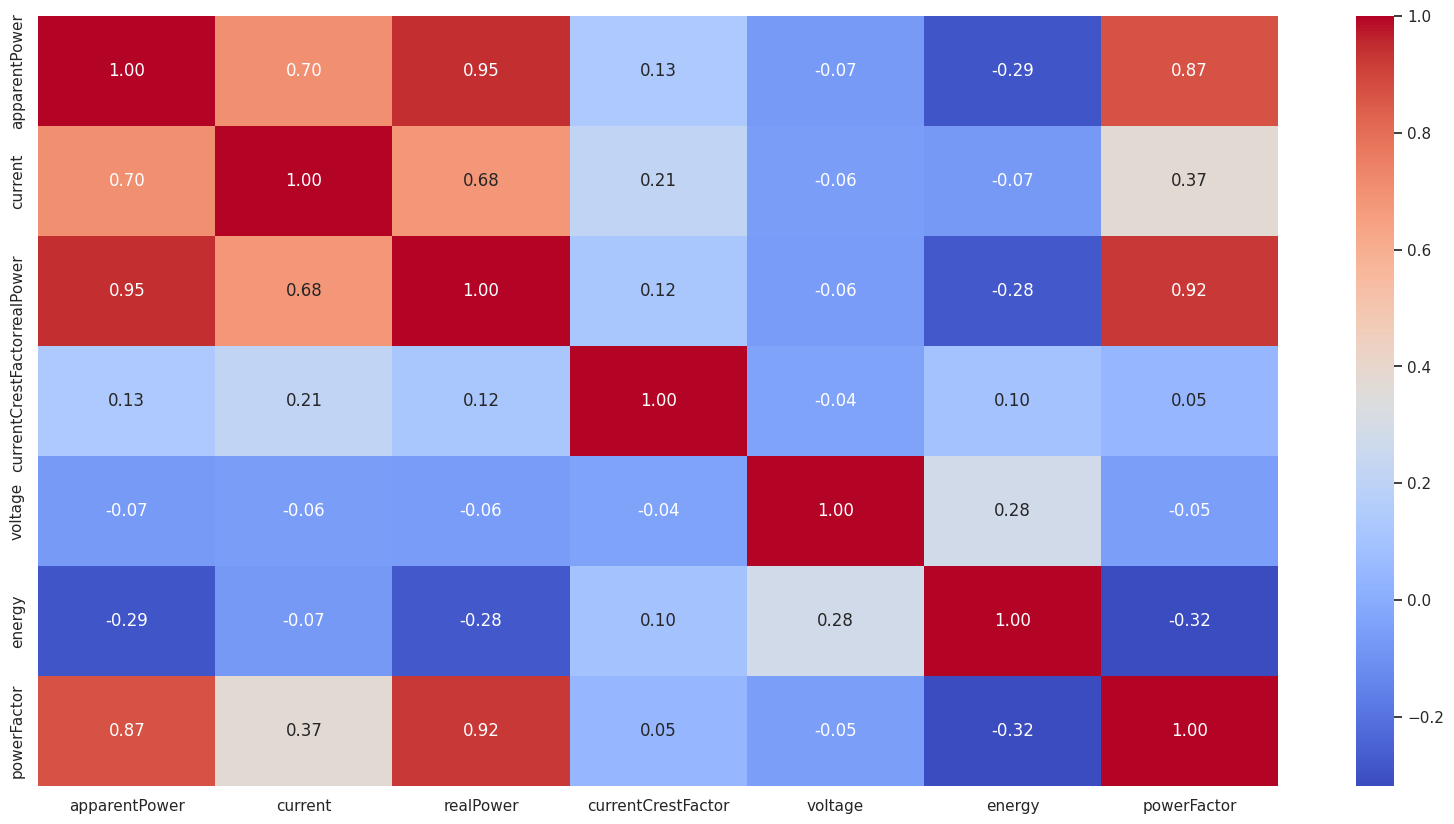

In [5]:
df_used = return_df(pdu_output_flat)
output_cols = common_cols[2:0] + pdu_cols
corr = df_used[output_cols].corr()

fig, ax = plt.subplots(figsize=(20, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

Event Rate subset:  [0, 10, 100, 1000, 100000]
Source CPU subset:  ['1', '10', '50']


<Axes: >

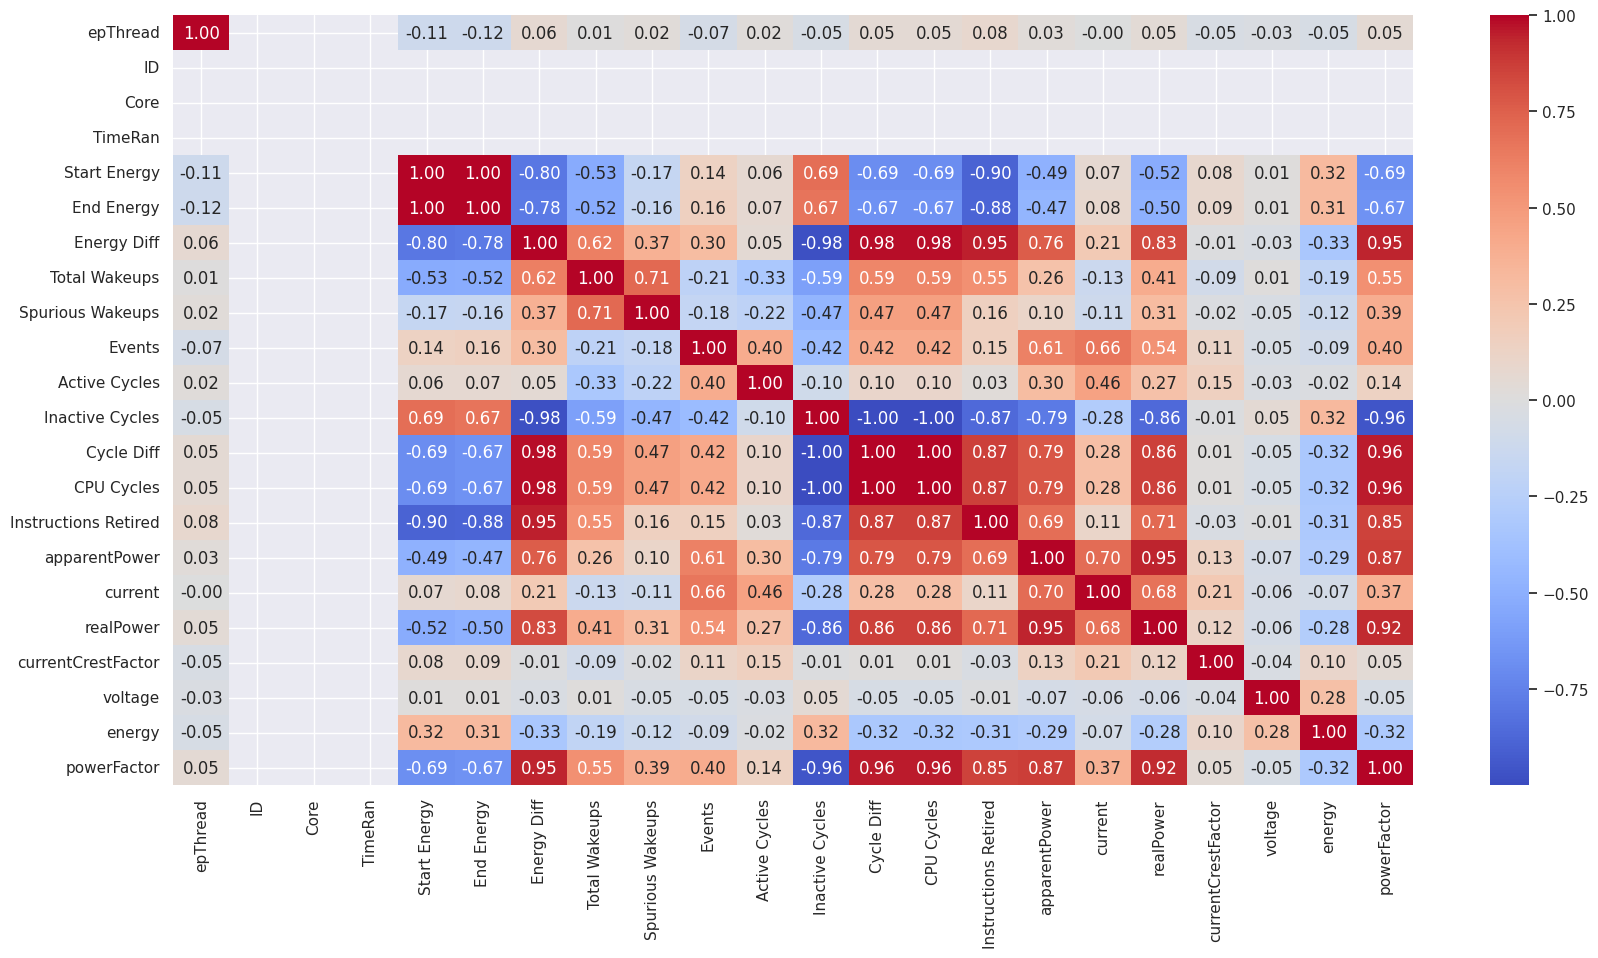

In [6]:
df_used = return_df(pdu_output_flat)
output_cols = bm_cols + pdu_cols
corr = df_used[output_cols].corr()

fig, ax = plt.subplots(figsize=(20, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

#### PDU Graphs

##### Choosing subsets of plots

In [7]:
#eventsubset=[10, 100]
#eventsubset=[50000, 100000, 150000]
#sourceCPUsubset=["1", "10", "50"]

## TODO remove 0 but make a copy so doesn't affect graphs above
#eventsubset.remove(0) # no 0 eventrate need because no latency there
df_used = return_df(bm_output_clean)

Event Rate subset:  [0, 10, 100, 1000, 100000]
Source CPU subset:  ['1', '10', '50']


0      54.2
1      53.9
2      53.9
3      54.0
4      53.9
       ... 
344    54.0
345    54.8
346    55.0
347    55.0
348    55.0
Name: realPower, Length: 349, dtype: object
Event Rate subset:  [0, 10, 100, 1000, 100000]
Source CPU subset:  ['1', '10', '50']


<Figure size 640x480 with 0 Axes>

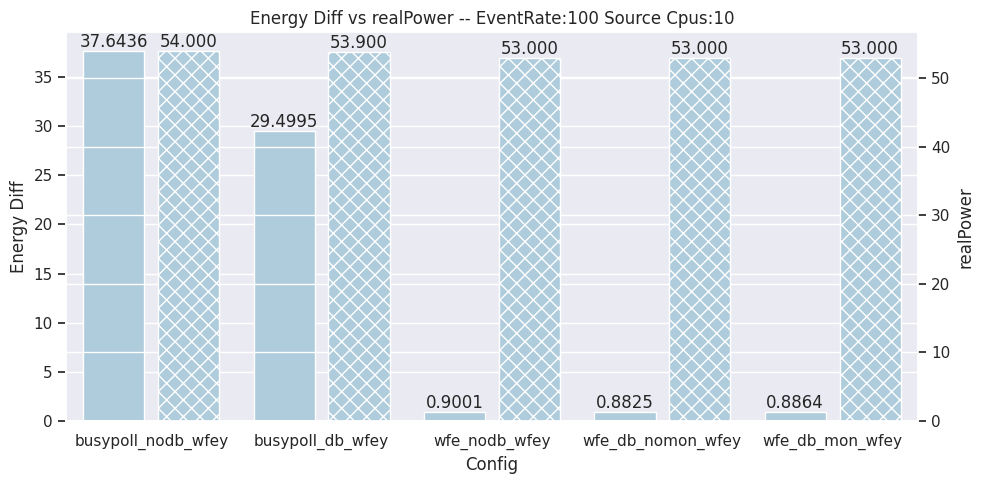

<Figure size 640x480 with 0 Axes>

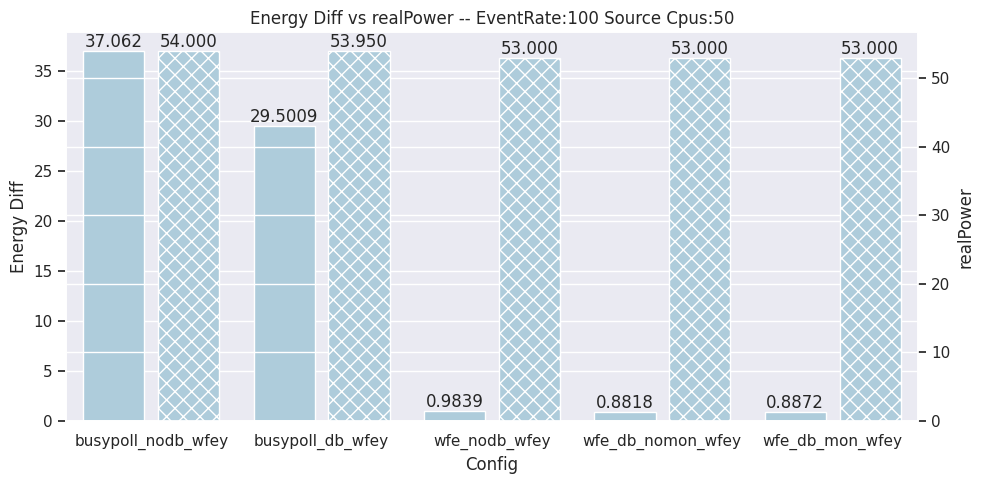

<Figure size 640x480 with 0 Axes>

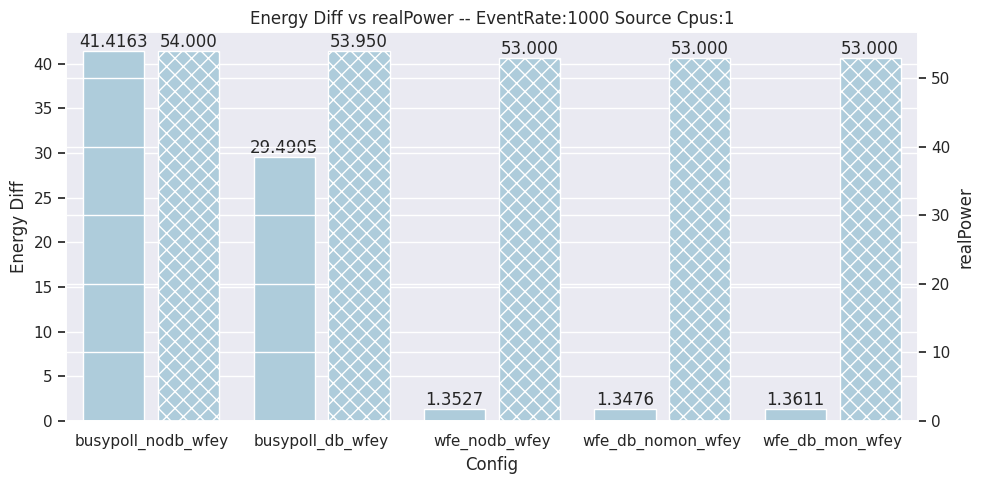

<Figure size 640x480 with 0 Axes>

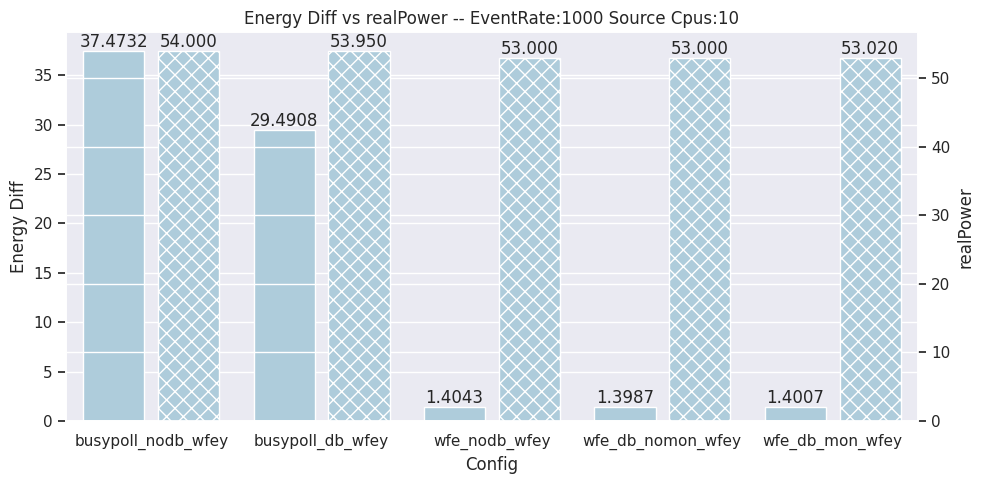

<Figure size 640x480 with 0 Axes>

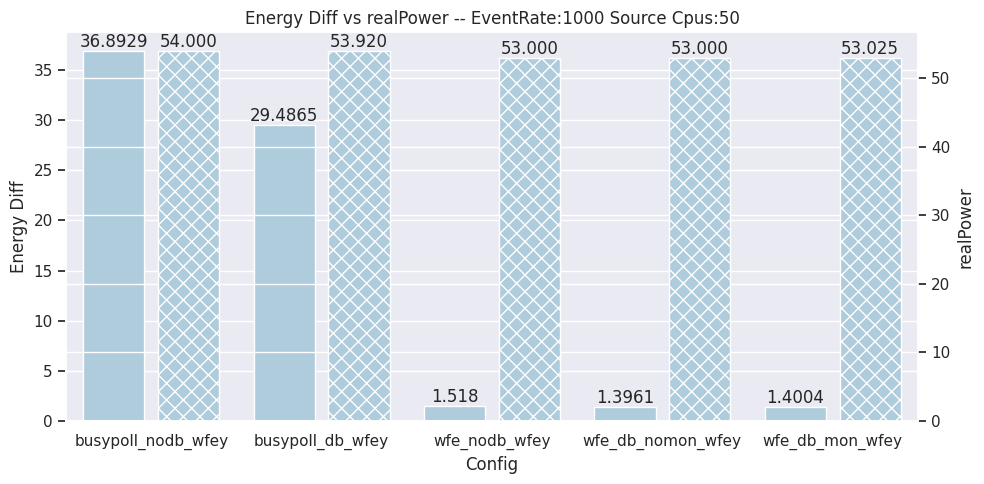

<Figure size 640x480 with 0 Axes>

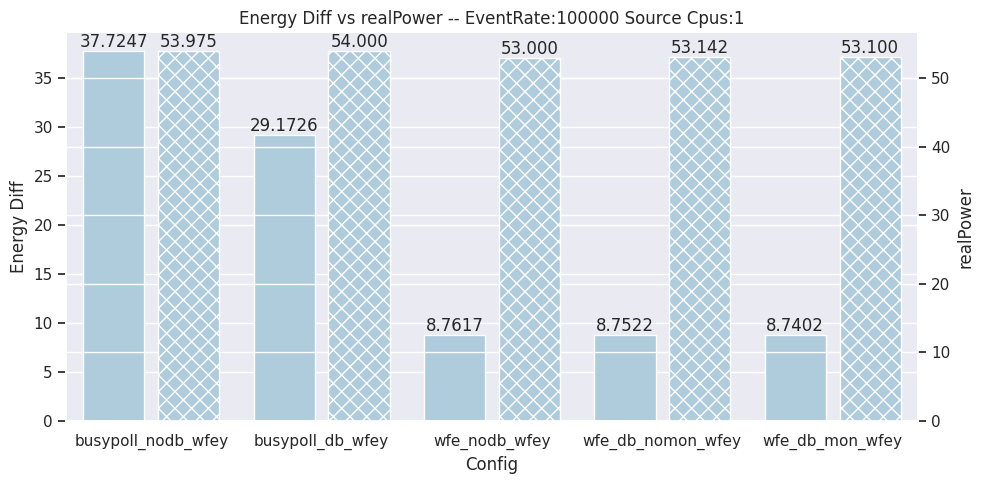

<Figure size 640x480 with 0 Axes>

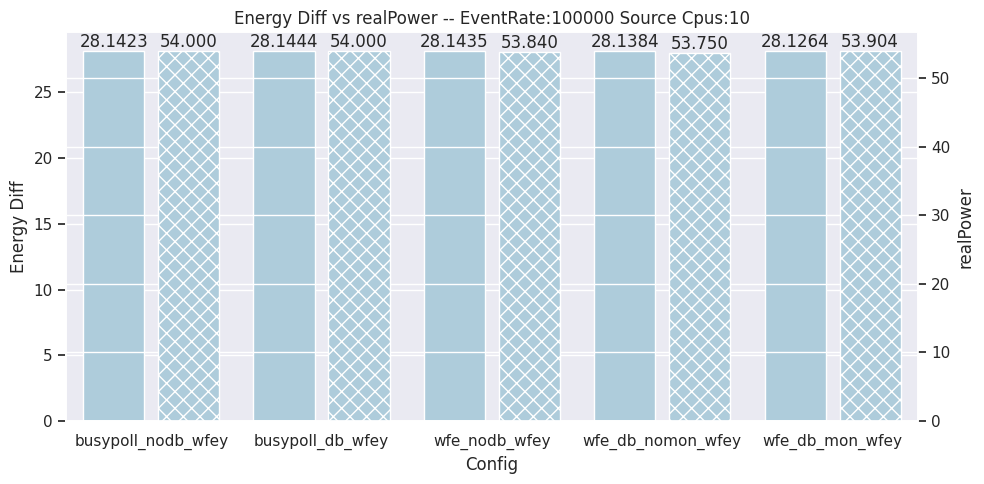

<Figure size 640x480 with 0 Axes>

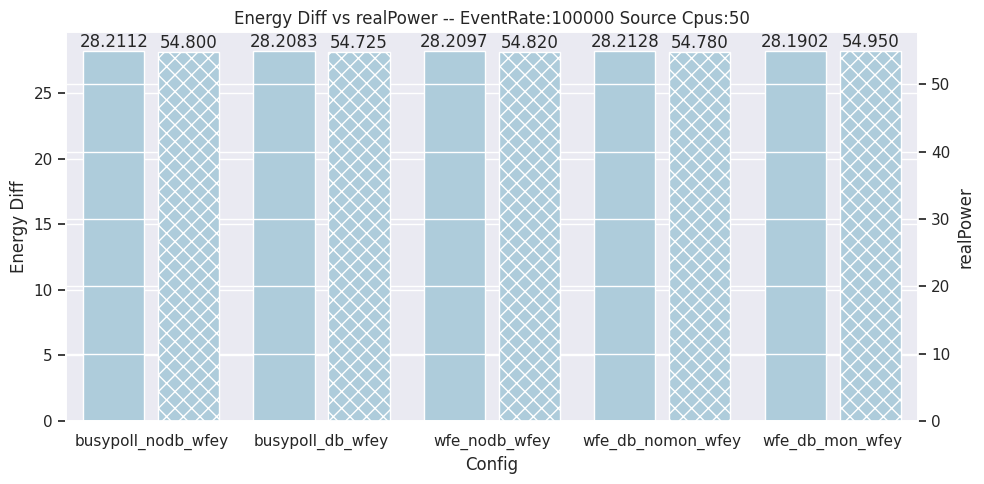

In [8]:
col='realPower'
print(pdu_output_flat[col])
bar_bar_across_configs(pdu_output_flat, sourceCPUsubset, eventsubset, ENERGY_COLUMN, col)
